# Final IV Imputation Model

This notebook documents the model that produced the best actual submission score so far: **actual MSE = `0.0000658973`**.

Best submission file: `submission_blend_p1rich03_90_surface2d10.csv`

Underlying filled file: `filled_blend_p1rich03_90_surface2d10.csv`

Final model:

`0.90 * PowerMICE(p=1.0, alpha=0.03, rich_features) + 0.10 * Local 2D IV Surface Smoother`

The 2D smoother is fit separately for CE and PE using local neighbors in both time and strike, with tighter time locality on expiry day.

## Why This Model

I first tried standard imputation families: forward/backward fill, row-wise strike interpolation, SoftImpute-style low-rank matrix completion, and MICE-style iterative ridge. Random 10% masking initially suggested very low scores, but actual submissions showed that random masks were too easy.

The important shift was using a **native-missing-pattern validation proxy**: for each row, I masked the same number of observed cells as were actually missing in that row. This tracked actual leaderboard behavior much better.

I also found that expiry mattered a lot. The IV curve close to expiry behaves very differently from the non-expiry region, especially when viewed against log-moneyness. That is why I explicitly tested `DTE < 1` and `DTE >= 1` behavior instead of assuming one smooth global pattern.

The best actual result came from a conservative blend: I kept most of the stable rich-feature PowerMICE prediction and added a small local 2D surface correction.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from advanced_imputation_search import expiry_features
from leakage_safe_imputation_eval import power_iterative_ridge
from no_leak_model_search_v2 import make_extra
from robust_imputation_search import load_data
from surface2d_search import local_surface_2d

DATASET_PATH = "dataset.csv"
FILLED_OUTPUT = "filled_blend_p1rich03_90_surface2d10.csv"
SUBMISSION_OUTPUT = "submission_blend_p1rich03_90_surface2d10.csv"
SEPARATOR = "||"

## 1. Load Dataset and Identify Option Columns

`load_data` parses the option names, extracts strike and CE/PE type, and sorts the IV columns by option type and strike. One important fix I made during modeling was parsing strikes correctly: `NIFTY27JAN2625200CE` means strike `25200`, not `2625200`.

In [2]:
df_model, option_cols, option_info = load_data(DATASET_PATH)
df_original = pd.read_csv(DATASET_PATH)

values = df_model[option_cols].to_numpy(dtype=float)
native_missing = np.isnan(values)

print("Shape:", df_model.shape)
print("IV columns:", len(option_cols))
print("Native missing IV cells:", int(native_missing.sum()))
print("Native missing %:", round(native_missing.mean() * 100, 4))
display(df_original.head())

Shape: (975, 30)
IV columns: 28
Native missing IV cells: 5460
Native missing %: 20.0


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


## 2. Expiry and Missingness EDA

The expiry is embedded in the option column names. I convert timestamps into days-to-expiry (`DTE`) and inspect how missingness is distributed across expiry day versus non-expiry rows.

This step matters because an option IV surface is not stationary through time. Close to expiry, small changes in spot and strike distance can create much sharper IV changes. If the expiry-day surface looks different, a single global imputation rule can underfit the hard region.


In [3]:
dte, intraday = expiry_features(df_model, option_cols)

eda = pd.DataFrame([
    {
        "group": "DTE < 1",
        "rows": int((dte < 1).sum()),
        "missing_cells": int(native_missing[dte < 1].sum()),
        "total_cells": int(native_missing[dte < 1].size),
        "missing_pct": float(native_missing[dte < 1].mean() * 100),
    },
    {
        "group": "DTE >= 1",
        "rows": int((dte >= 1).sum()),
        "missing_cells": int(native_missing[dte >= 1].sum()),
        "total_cells": int(native_missing[dte >= 1].size),
        "missing_pct": float(native_missing[dte >= 1].mean() * 100),
    },
])

display(eda)
print(pd.Series(dte).describe())

,group,rows,missing_cells,total_cells,missing_pct
0,DTE < 1,75,408,2100,19.428571
1,DTE >= 1,900,5052,25200,20.047619


count    975.000000
mean      10.901175
std        6.069294
min        0.003472
25%        6.067708
50%       11.131944
75%       15.196181
max       20.260417
dtype: float64


## 2.1 IV vs Log-Moneyness

To decide whether expiry day should be handled separately, I plotted observed IV against log-moneyness:

`log_moneyness = log(strike / underlying_price)`

This is more informative than plotting against raw strike because it normalizes strikes by the current underlying price. The plot compares median observed IV in log-moneyness bins for `DTE < 1` and `DTE >= 1`.

The expiry-day curve is much steeper and sits in a very different IV range. This gave me a concrete reason to test expiry-aware features and local smoothing instead of treating every row as part of one homogeneous matrix.


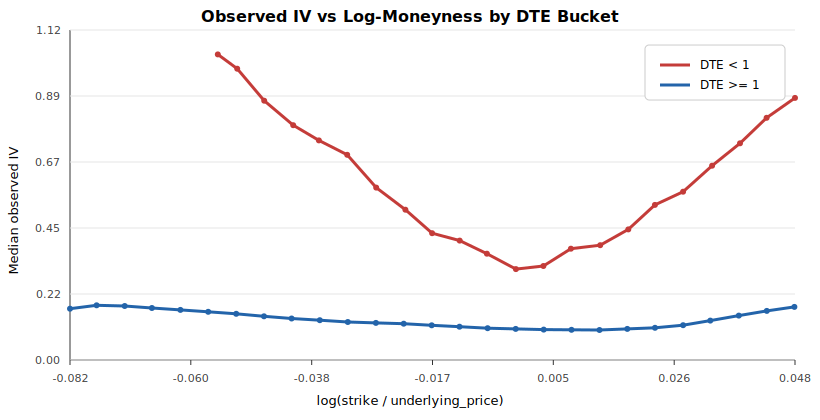

median_iv                                                   \
              count      mean       std      min       25%       50%   
dte_group                                                              
DTE < 1        22.0  0.611532  0.224428  0.30785  0.410888  0.577143   
DTE >= 1       27.0  0.137830  0.028739  0.10170  0.110973  0.133520   

                               
                75%       max  
dte_group                      
DTE < 1    0.782584  1.035170  
DTE >= 1   0.164735  0.185385

In [4]:
from IPython.display import SVG, display

# Build long-form observed IV data with log-moneyness.
records = []
for j, col in enumerate(option_cols):
    strike = option_info[col]["strike"]
    opt_type = option_info[col]["type"]
    observed_rows = np.where(~np.isnan(values[:, j]))[0]
    for i in observed_rows:
        records.append({
            "dte_group": "DTE < 1" if dte[i] < 1 else "DTE >= 1",
            "option_type": opt_type,
            "log_moneyness": np.log(strike / df_model.loc[i, "underlying_price"]),
            "iv": values[i, j],
        })

iv_long = pd.DataFrame(records)

# Bin log-moneyness and compute median IV per group/bin.
bins = np.linspace(iv_long["log_moneyness"].quantile(0.01), iv_long["log_moneyness"].quantile(0.99), 28)
iv_long["lm_bin"] = pd.cut(iv_long["log_moneyness"], bins=bins, include_lowest=True)
curve = (
    iv_long
    .groupby(["dte_group", "lm_bin"], observed=True)
    .agg(log_moneyness=("log_moneyness", "mean"), median_iv=("iv", "median"), n=("iv", "size"))
    .reset_index()
)
curve = curve[curve["n"] >= 8]

def svg_line_plot(curve_df, width=820, height=420):
    margin = {"left": 70, "right": 25, "top": 30, "bottom": 60}
    plot_w = width - margin["left"] - margin["right"]
    plot_h = height - margin["top"] - margin["bottom"]
    x_min, x_max = curve_df["log_moneyness"].min(), curve_df["log_moneyness"].max()
    y_min, y_max = 0, curve_df["median_iv"].max() * 1.08

    def sx(x):
        return margin["left"] + (x - x_min) / (x_max - x_min) * plot_w

    def sy(y):
        return margin["top"] + (y_max - y) / (y_max - y_min) * plot_h

    colors = {"DTE < 1": "#c43c39", "DTE >= 1": "#2364aa"}
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    parts.append('<rect width="100%" height="100%" fill="white"/>')
    parts.append(f'<line x1="{margin["left"]}" y1="{height-margin["bottom"]}" x2="{width-margin["right"]}" y2="{height-margin["bottom"]}" stroke="#333"/>')
    parts.append(f'<line x1="{margin["left"]}" y1="{margin["top"]}" x2="{margin["left"]}" y2="{height-margin["bottom"]}" stroke="#333"/>')

    for frac in np.linspace(0, 1, 6):
        y = y_min + frac * (y_max - y_min)
        py = sy(y)
        parts.append(f'<line x1="{margin["left"]}" y1="{py:.1f}" x2="{width-margin["right"]}" y2="{py:.1f}" stroke="#e6e6e6"/>')
        parts.append(f'<text x="{margin["left"]-10}" y="{py+4:.1f}" text-anchor="end" font-size="11" fill="#444">{y:.2f}</text>')

    for frac in np.linspace(0, 1, 7):
        x = x_min + frac * (x_max - x_min)
        px = sx(x)
        parts.append(f'<line x1="{px:.1f}" y1="{height-margin["bottom"]}" x2="{px:.1f}" y2="{height-margin["bottom"]+5}" stroke="#333"/>')
        parts.append(f'<text x="{px:.1f}" y="{height-margin["bottom"]+22}" text-anchor="middle" font-size="11" fill="#444">{x:.3f}</text>')

    for group, group_df in curve_df.groupby("dte_group"):
        group_df = group_df.sort_values("log_moneyness")
        pts = " ".join(f'{sx(x):.1f},{sy(y):.1f}' for x, y in zip(group_df["log_moneyness"], group_df["median_iv"]))
        parts.append(f'<polyline fill="none" stroke="{colors[group]}" stroke-width="3" points="{pts}"/>')
        for x, y in zip(group_df["log_moneyness"], group_df["median_iv"]):
            parts.append(f'<circle cx="{sx(x):.1f}" cy="{sy(y):.1f}" r="3" fill="{colors[group]}"/>')

    parts.append(f'<text x="{width/2}" y="22" text-anchor="middle" font-size="16" font-weight="600">Observed IV vs Log-Moneyness by DTE Bucket</text>')
    parts.append(f'<text x="{width/2}" y="{height-15}" text-anchor="middle" font-size="13">log(strike / underlying_price)</text>')
    parts.append(f'<text x="18" y="{height/2}" text-anchor="middle" font-size="13" transform="rotate(-90 18 {height/2})">Median observed IV</text>')
    parts.append(f'<rect x="{width-175}" y="45" width="140" height="55" rx="4" fill="white" stroke="#ccc"/>')
    parts.append(f'<line x1="{width-160}" y1="65" x2="{width-130}" y2="65" stroke="{colors["DTE < 1"]}" stroke-width="3"/><text x="{width-120}" y="69" font-size="12">DTE &lt; 1</text>')
    parts.append(f'<line x1="{width-160}" y1="85" x2="{width-130}" y2="85" stroke="{colors["DTE >= 1"]}" stroke-width="3"/><text x="{width-120}" y="89" font-size="12">DTE &gt;= 1</text>')
    parts.append('</svg>')
    return "".join(parts)

display(SVG(svg_line_plot(curve)))
display(curve.groupby("dte_group")[["median_iv"]].describe())


## 3. Rich Features for PowerMICE

The base model is an iterative ridge imputer, equivalent in spirit to MICE. Each option column is repeatedly predicted from the other option columns plus row-level market/time features.

The `rich_features` matrix includes:

- underlying price
- row/time index
- DTE and intraday time
- expiry-day flag
- sinusoidal time features
- underlying price differences/rolling behavior
- DTE transforms such as `log1p(DTE)` and `1/sqrt(DTE)`

In [5]:
extra_rich = make_extra(df_model, dte, intraday, variant="rich")
print("Rich feature matrix shape:", extra_rich.shape)

Rich feature matrix shape: (975, 12)


## 3.1 Why I Chose PowerMICE

The EDA led me toward a MICE-style model for three reasons:

1. **The IV columns are strongly related.** Neighboring strikes and same-type options move together, so a missing IV can be predicted from the rest of the row.
2. **The relationship is multivariate.** A missing value is not only a function of its own column history; it also depends on the whole option surface, underlying price, DTE, and intraday time.
3. **The expiry split showed non-stationarity.** Because `DTE < 1` behaves differently, I needed a model that can use DTE and expiry-day features directly.

PowerMICE is my name here for a transformed MICE/Iterative Ridge imputer:

- I optionally transform IV as `IV^power`.
- I iteratively predict each option column from the other option columns plus engineered row features.
- I use ridge regularization (`alpha`) to control overfitting.
- I transform predictions back to IV scale.

The best actual model used `power=1.0`, so it worked directly on raw IV, with `alpha=0.03` and the rich feature set.


## 4. Base Model: PowerMICE(p=1.0, alpha=0.03, rich)

Earlier PowerMICE settings using concave transforms such as `p=0.27` performed very well under random masking, but actual submissions showed that they did not transfer as well to native missing cells.

The native-pattern proxy and actual submissions both favored a raw-scale model:

`PowerMICE(power=1.0, alpha=0.03, rich_features)`

In [6]:
p1rich03 = power_iterative_ridge(
    values,
    extra_rich,
    power=1.0,
    alpha=0.03,
)

print("Base model matrix shape:", p1rich03.shape)
print("Base model min/max:", float(np.nanmin(p1rich03)), float(np.nanmax(p1rich03)))

Base model matrix shape: (975, 28)
Base model min/max: 0.0168 5.634304022318808


## 5. Local 2D IV Surface Smoother

The second component uses nearby observations in a local time-strike window. It is fit separately for calls and puts.

Final smoother settings:

- `power=0.85`
- `method="plane"`
- `expiry_time_scale=0.75`
- `non_time_scale=4.0`
- fallback = the PowerMICE base model

The small `10%` weight was important. Larger surface weights performed worse because local surface interpolation can be unstable when a row has many missing strikes.

## 5.1 Why I Combined PowerMICE with Local Smoothing

PowerMICE gave the most stable global predictions because it used the full option surface and time/expiry features. However, the IV graph showed that the surface can become very steep near expiry. A global linear ridge model can smooth over some of these local curve details.

The local 2D smoother solves a different problem:

- It looks at nearby timestamps and nearby strikes.
- It fits CE and PE separately.
- It uses tighter time locality when `DTE < 1`.
- It captures local shape details that a global model can miss.

The smoother alone was too unstable when many neighboring strikes were missing, so I used it only as a correction to the stronger PowerMICE backbone.


In [7]:
surface2d = local_surface_2d(
    values,
    option_cols,
    option_info,
    dte,
    power=0.85,
    method="plane",
    expiry_time_scale=0.75,
    non_time_scale=4.0,
    fallback=p1rich03,
)

print("Surface model matrix shape:", surface2d.shape)
print("Surface model min/max:", float(np.nanmin(surface2d)), float(np.nanmax(surface2d)))

Surface model matrix shape: (975, 28)
Surface model min/max: 0.0168 5.738024364790862


## 5.2 Why the Final Ratio is 90/10

I tested conservative blends because the local 2D smoother was useful but noisy. Larger smoothing weights made validation less stable, especially on rows with many missing strikes. The most reliable actual submission came from a small correction:

`90% PowerMICE + 10% local 2D surface smoother`

This ratio keeps the global consistency of PowerMICE while allowing the local surface model to adjust hard time-strike regions, especially around expiry day.


## 6. Final Blend and Filled CSV

The final model is:

`final = 0.90 * p1rich03 + 0.10 * surface2d`

Only originally missing cells are replaced. All originally observed IV values are preserved exactly.

In [8]:
final_matrix = 0.90 * p1rich03 + 0.10 * surface2d

filled_values = values.copy()
filled_values[native_missing] = final_matrix[native_missing]
filled_values = np.clip(filled_values, 1e-8, None)

filled_df = df_original.copy()
filled_df[option_cols] = filled_values
filled_df.to_csv(FILLED_OUTPUT, index=False)

print("Saved filled CSV:", FILLED_OUTPUT)
print("Remaining missing IV cells:", int(filled_df[option_cols].isna().sum().sum()))
print("Max observed-cell change:", float(np.nanmax(np.abs((filled_df[option_cols].to_numpy(dtype=float) - values)[~native_missing]))))

Saved filled CSV: filled_blend_p1rich03_90_surface2d10.csv
Remaining missing IV cells: 0
Max observed-cell change: 0.0


## 7. Convert Filled CSV to Submission Format

The competition submission contains one row for every originally missing cell. The ID is:

`datetime || column_name`

In [9]:
def generate_solution(filled_path: str, output_path: str = SUBMISSION_OUTPUT):
    original = pd.read_csv(DATASET_PATH)
    filled = pd.read_csv(filled_path)

    feature_cols = [c for c in original.columns if c != "datetime"]

    rows = []
    for col in feature_cols:
        was_missing = original[col].isna()

        for idx in original.index[was_missing]:
            dt = original.loc[idx, "datetime"]
            uid = f"{dt}{SEPARATOR}{col}"
            val = filled.loc[idx, col]
            rows.append({"id": uid, "value": val})

    solution = pd.DataFrame(rows, columns=["id", "value"])
    solution = solution.sort_values("id").reset_index(drop=True)
    solution.to_csv(output_path, index=False)
    print(f"Solution saved -> {output_path} ({len(solution)} rows)")
    return solution

solution = generate_solution(FILLED_OUTPUT, SUBMISSION_OUTPUT)
display(solution.head())

Solution saved -> submission_blend_p1rich03_90_surface2d10.csv (5460 rows)


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.164017
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.114925
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.100423
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.173224
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.163273


## 8. Final Notes

I did not select the final model from random validation alone. Random masks were too optimistic because they did not resemble the real missing-cell structure.

The model that generalized best to actual submissions used:

- a stable global iterative ridge/MICE backbone on raw IV scale
- rich time/expiry/underlying features
- a small local 2D surface correction
- exact preservation of observed cells

Actual best score recorded for this model/submission: `0.0000658973`.